# Likelihood Field from a Small Grid Map

This notebook teaches how a **20×20 grid map** is used to **precompute a likelihood field** for sensor-based localization (e.g. MCL). You will see:

1. **Occupancy grid**: free (0) vs occupied (1) cells.
2. **Distance map**: precomputed distance from every cell to the nearest occupied cell (expand or SciPy EDT).
3. **Query-cell visualizations**: using the precomputed distance map and (when requested) precomputed nearest-obstacle indices from Section 2.
4. **Likelihood field**: converting distance to likelihood (Gaussian) and viewing the numbers on the grid.

## 1. Imports and a 20×20 occupancy grid

/home/scotrraaj.gopal/Scot_HBRS/Semester_1/AMR/ros2_ws/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


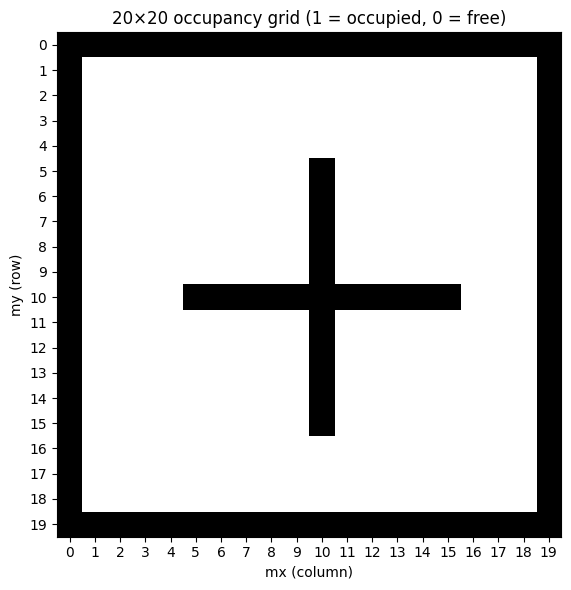

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SIZE = 20
grid = np.zeros((SIZE, SIZE), dtype=np.int32)
grid[0, :] = grid[-1, :] = grid[:, 0] = grid[:, -1] = 1
grid[10, 5:16] = 1
grid[5:16, 10] = 1

def _grid_axes(ax, n, xlabel="mx", ylabel="my"):
    """Set ticks and labels for an n×n grid plot (shared across notebook)."""
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(np.arange(n))
    ax.set_yticklabels(np.arange(n))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_grid_values(ax, grid, values, title, cmap, fmt=".2f", wall_label="W", text_white_below=0.5):
    """Draw values in each cell; occupied cells show wall_label. text_white_below: use white text when value < this."""
    ax.imshow(values, cmap=cmap, origin="upper", vmin=0, vmax=1 if values.max() <= 1.01 else None)
    h, w = grid.shape
    for my in range(h):
        for mx in range(w):
            if grid[my, mx] > 0:
                ax.text(mx, my, wall_label, ha="center", va="center", color="white", fontsize=8, fontweight="bold")
            else:
                val = values[my, mx]
                color = "white" if val < text_white_below else "black"
                ax.text(mx, my, f"{val:{fmt}}", ha="center", va="center", color=color, fontsize=6)
    _grid_axes(ax, h)
    ax.set_title(title)


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(grid, cmap="binary", origin="upper", vmin=0, vmax=1)
_grid_axes(ax, SIZE, "mx (column)", "my (row)")
ax.set_title("20×20 occupancy grid (1 = occupied, 0 = free)")
plt.tight_layout()
plt.show()

## 2. Precompute the full distance map

For **every** cell we store the distance to the nearest occupied cell. This is the **distance transform** (or "distance map").

`compute_distance_map` supports:
- **method**: `'expand'` (expanding-square search) or `'edt'` (SciPy EDT).
- **return_indices**: if `True`, also returns nearest-obstacle indices (shape `(2, H, W)`) for drawing query→obstacle links in the visualizations. If you only need the distance map (e.g. for the likelihood field), set `RETURN_INDICES_FOR_VIZ = False` so indices are not computed.

In [2]:
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

def distance_to_nearest_obstacle(grid, mx, my, max_search=25):
    """
    Euclidean distance (in cells) from a grid cell to the nearest occupied cell.

    Uses an expanding-square search: checks radius 0, then 1, 2, ... until an
    occupied cell is found.

    Parameters
    ----------
    grid : np.ndarray
        2D occupancy grid (0 = free, 1 = occupied).
    mx, my : int
        Column and row indices of the query cell.
    max_search : int, optional
        Maximum search radius in cells (default 25).

    Returns
    -------
    float
        Euclidean distance in cells to nearest occupied cell, or inf if none found
        within max_search or (mx, my) is out of bounds.
    """
    h, w = grid.shape
    if mx < 0 or mx >= w or my < 0 or my >= h:
        logger.warning(
            "Query cell (mx=%s, my=%s) is out of grid bounds (0..%s, 0..%s); returning inf",
            mx, my, w - 1, h - 1
        )
        return float('inf')
    for r in range(0, max_search + 1):
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                if dx == 0 and dy == 0 and r > 0:
                    continue
                nx, ny = mx + dx, my + dy
                if 0 <= nx < w and 0 <= ny < h and grid[ny, nx] > 0:
                    return np.sqrt(float(dx*dx + dy*dy))
    logger.debug(
        "No occupied cell found within radius %s at (mx=%s, my=%s); returning inf",
        max_search, mx, my
    )
    return float('inf')


def find_nearest_obstacle_cell(grid, mx, my, max_search=25):
    """
    Find the nearest occupied cell to (mx, my) and return distance and its indices.

    Uses the same expanding-square search as distance_to_nearest_obstacle.

    Parameters
    ----------
    grid : np.ndarray
        2D occupancy grid (0 = free, 1 = occupied).
    mx, my : int
        Column and row indices of the query cell.
    max_search : int, optional
        Maximum search radius in cells (default 25).

    Returns
    -------
    tuple of (float, tuple of (int | None, int | None))
        (distance_in_cells, (nx, ny)) where (nx, ny) is the nearest occupied
        cell, or (inf, (None, None)) if none found or out of bounds.
    """
    h, w = grid.shape
    if mx < 0 or mx >= w or my < 0 or my >= h:
        logger.warning(
            "Query cell (mx=%s, my=%s) is out of grid bounds (0..%s, 0..%s); returning (inf, (None, None))",
            mx, my, w - 1, h - 1
        )
        return float('inf'), (None, None)
    for r in range(0, max_search + 1):
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                if dx == 0 and dy == 0 and r > 0:
                    continue
                nx, ny = mx + dx, my + dy
                if 0 <= nx < w and 0 <= ny < h and grid[ny, nx] > 0:
                    d = np.sqrt(float(dx*dx + dy*dy))
                    return d, (nx, ny)
    logger.info(
        "No occupied cell found within radius %s at (mx=%s, my=%s); returning (inf, (None, None))",
        max_search, mx, my
    )
    return float('inf'), (None, None)


def get_nearest_obstacle(nearest_obstacle_indices, row, col):
    """
    Return (nx, ny) of nearest occupied cell from precomputed indices, or (None, None).

    Parameters
    ----------
    nearest_obstacle_indices : np.ndarray or None
        Shape (2, H, W): [row, col] per cell; -1 means no obstacle (expand only).
    row, col : int
        Query cell (y, x).

    Returns
    -------
    tuple of (int | None, int | None)
        (nx, ny) column and row of nearest obstacle, or (None, None).
    """
    if nearest_obstacle_indices is None:
        return None, None
    ny = int(nearest_obstacle_indices[0][row, col])
    nx = int(nearest_obstacle_indices[1][row, col])
    if nx < 0 or ny < 0:
        return None, None
    return nx, ny

Distance map: method=edt, return_indices=True


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


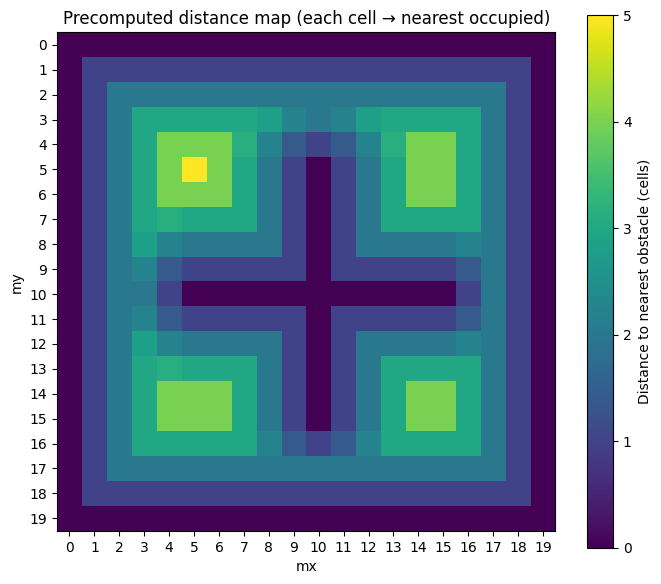

In [3]:
def compute_distance_map(grid, method='expand', return_indices=False, max_dist=15.0):
    """
    Precompute distance (in cells) from each cell to the nearest occupied cell.

    Parameters
    ----------
    grid : np.ndarray
        2D occupancy grid (0 = free, 1 = occupied).
    method : {'expand', 'edt'}, optional
        'expand': expanding-square search per cell (simple, O(n * r^2)).
        'edt': SciPy Euclidean distance transform (linear time). Default 'expand'.
    return_indices : bool, optional
        If True, also return nearest-obstacle indices (for visualization).
        When False, only the distance map is returned (e.g. for likelihood field).
        Default False.
    max_dist : float, optional
        Maximum distance to compute; larger distances are capped (default 15.0).
        Used only for method='expand'.

    Returns
    -------
    np.ndarray or tuple
        If return_indices is False: 2D float32 array of same shape as grid
        (distance to nearest obstacle at each cell, capped at max_dist for expand).
        If return_indices is True: (dist_map, nearest_obstacle_indices) where
        nearest_obstacle_indices has shape (2, H, W) with [row, col] of the
        nearest occupied cell per cell; use -1 for row/col when none found (expand only).
    """
    h, w = grid.shape
    if method == 'edt':
        from scipy.ndimage import distance_transform_edt
        free = (grid == 0).astype(np.float64)
        if return_indices:
            dist, inds = distance_transform_edt(free, return_indices=True)
            return dist.astype(np.float32), inds
        dist = distance_transform_edt(free)
        return dist.astype(np.float32)

    # method == 'expand'
    max_search = int(max_dist) + 1
    dist = np.full((h, w), max_dist, dtype=np.float32)
    if return_indices:
        inds = np.zeros((2, h, w), dtype=np.int32)
        inds.fill(-1)
    for my in range(h):
        for mx in range(w):
            d, (nx, ny) = find_nearest_obstacle_cell(grid, mx, my, max_search=max_search)
            dist[my, mx] = min(d, max_dist)
            if return_indices and nx is not None and ny is not None:
                inds[0, my, mx] = ny
                inds[1, my, mx] = nx
    if return_indices:
        return dist, inds
    return dist

# --- Section 2: compute the distance map (and optionally indices for visualization) ---
# Method: 'expand' (expanding-square) or 'edt' (SciPy EDT).
USE_EDT = True
method = 'edt' if USE_EDT else 'expand'
# Set True only when you need nearest-obstacle indices for the query-cell visualizations.
# For building the likelihood field alone, False is enough (saves work for EDT).
RETURN_INDICES_FOR_VIZ = True

result = compute_distance_map(grid, method=method, return_indices=RETURN_INDICES_FOR_VIZ, max_dist=15.0)
if RETURN_INDICES_FOR_VIZ:
    dist_map, nearest_obstacle_indices = result
else:
    dist_map = result
    nearest_obstacle_indices = None

print(f"Distance map: method={method}, return_indices={RETURN_INDICES_FOR_VIZ}")

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.imshow(dist_map, cmap="viridis", origin="upper")
plt.colorbar(im, ax=ax, label="Distance to nearest obstacle (cells)")
_grid_axes(ax, SIZE)
ax.set_title("Precomputed distance map (each cell → nearest occupied)")
plt.tight_layout()
plt.show()

## 3. Finding the closest occupied cell (using the precomputed distance map)

We use the **precomputed distance map** from Section 2 for the distance at any query cell: `dist_map[my, mx]`. To draw the link from query cell to the **nearest occupied cell**, the visualizations use only the **precomputed nearest-obstacle indices** from Section 2 (run Section 2 with `RETURN_INDICES_FOR_VIZ = True` to see the links).

### Visualize: single query cell

Pick a **query cell** (e.g. center of a free region). We show the distance from the precomputed map and, when Section 2 provided indices, the **nearest occupied cell** (red star) and a circle at that distance.

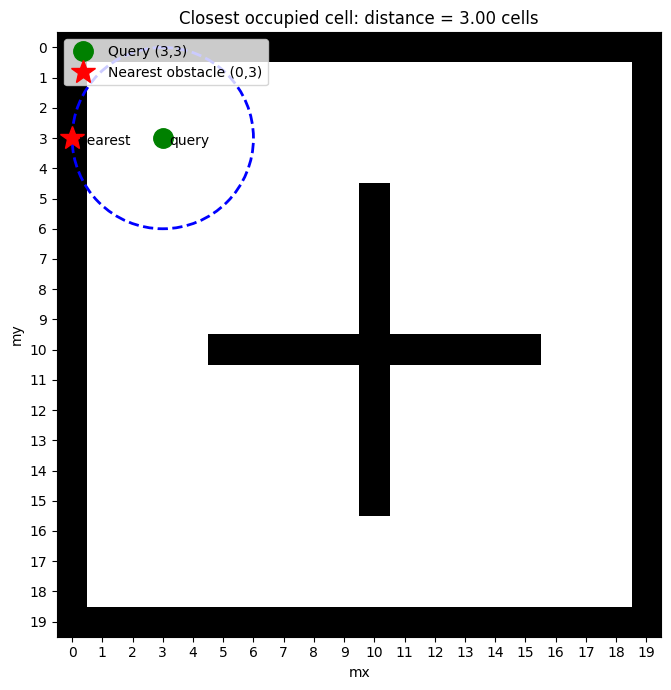

In [4]:
# Query cell: somewhere in the free space (e.g. top-left room center)
query_mx, query_my = 3, 3
d_cells = float(dist_map[query_my, query_mx])
nearest_nx, nearest_ny = get_nearest_obstacle(nearest_obstacle_indices, query_my, query_mx)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(grid, cmap="binary", origin="upper", vmin=0, vmax=1)

# Draw search radius (circle at distance d_cells)
circle = plt.Circle((query_mx, query_my), d_cells, fill=False, color='blue', linewidth=2, linestyle='--')
ax.add_patch(circle)

# Query cell
ax.plot(query_mx, query_my, 'go', markersize=14, label=f'Query ({query_mx},{query_my})')
ax.annotate('query', (query_mx, query_my), xytext=(5, -5), textcoords='offset points', fontsize=10)

# Nearest occupied cell
if nearest_nx is not None:
    ax.plot(nearest_nx, nearest_ny, 'r*', markersize=18, label=f'Nearest obstacle ({nearest_nx},{nearest_ny})')
    ax.annotate('nearest', (nearest_nx, nearest_ny), xytext=(5, -5), textcoords='offset points', fontsize=10)

_grid_axes(ax, SIZE)
ax.set_title(f"Closest occupied cell: distance = {d_cells:.2f} cells")
ax.legend(loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Visualize: search for multiple query cells

For several free cells we show **which occupied cell** is nearest (arrow or same-color link).

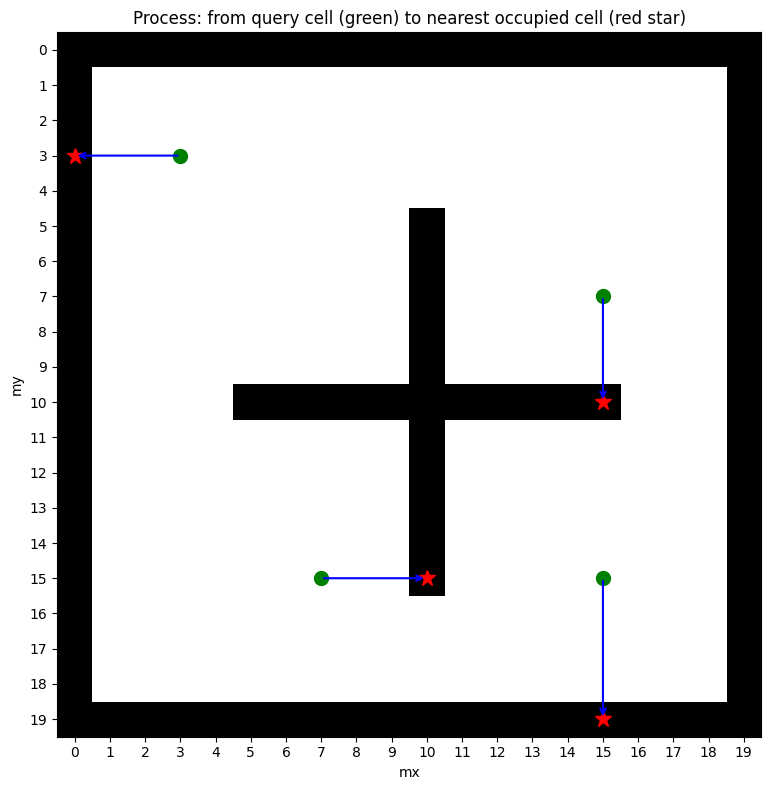

In [5]:
queries = [(3, 3), (15, 15), (7, 15), (15, 7)]  # four example cells

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(grid, cmap="binary", origin="upper", vmin=0, vmax=1)

for qx, qy in queries:
    if grid[qy, qx] > 0:
        continue
    ax.plot(qx, qy, 'go', markersize=10)
    nx, ny = get_nearest_obstacle(nearest_obstacle_indices, qy, qx)
    if nx is not None:
        ax.annotate('', xy=(nx, ny), xytext=(qx, qy),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
        ax.plot(nx, ny, 'r*', markersize=12)

_grid_axes(ax, SIZE)
ax.set_title("Process: from query cell (green) to nearest occupied cell (red star)")
plt.tight_layout()
plt.show()

## 4. Likelihood field and likelihood numbers

In **likelihood-field** localization we turn distance into a **likelihood**. A common model is a Gaussian in distance:

$$p(z \mid x) \propto \exp\left(-\frac{1}{2} \left(\frac{d}{\sigma}\right)^2\right)$$

So: **small distance** → high likelihood (beam endpoint near a wall); **large distance** → low likelihood. We use a small grid so we can **show the numbers** in a diagram.

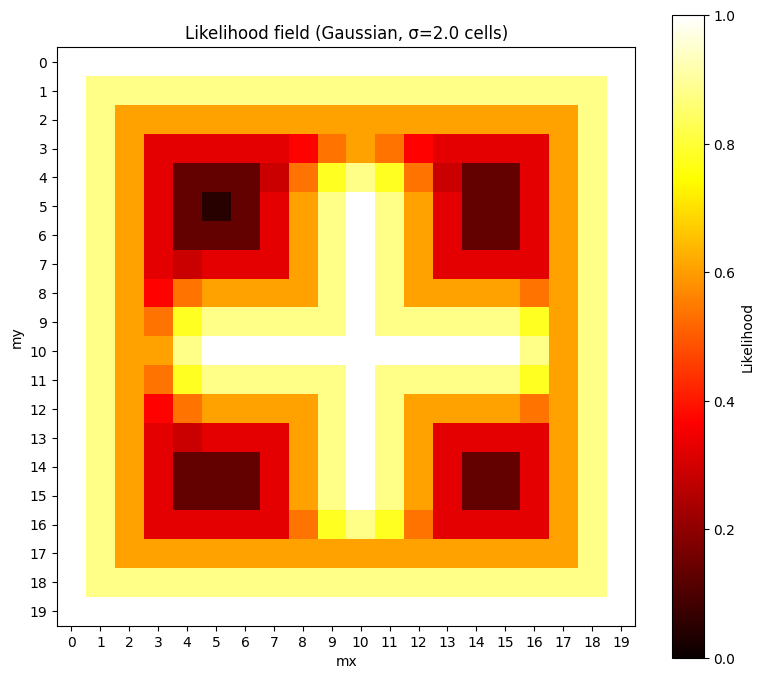

In [6]:
sigma = 2.0  # scale parameter (in cells)
likelihood = np.exp(-0.5 * (dist_map / sigma) ** 2)
# Occupied cells: distance 0 → likelihood 1
likelihood[grid > 0] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
im = ax.imshow(likelihood, cmap="hot", origin="upper", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Likelihood")
_grid_axes(ax, SIZE)
ax.set_title(f"Likelihood field (Gaussian, σ={sigma} cells)")
plt.tight_layout()
plt.show()

### Diagram with likelihood numbers on the grid

Below we show the **numeric likelihood** in each cell (rounded) so you can see how the field looks. Occupied cells are drawn as walls; free cells show their likelihood value.

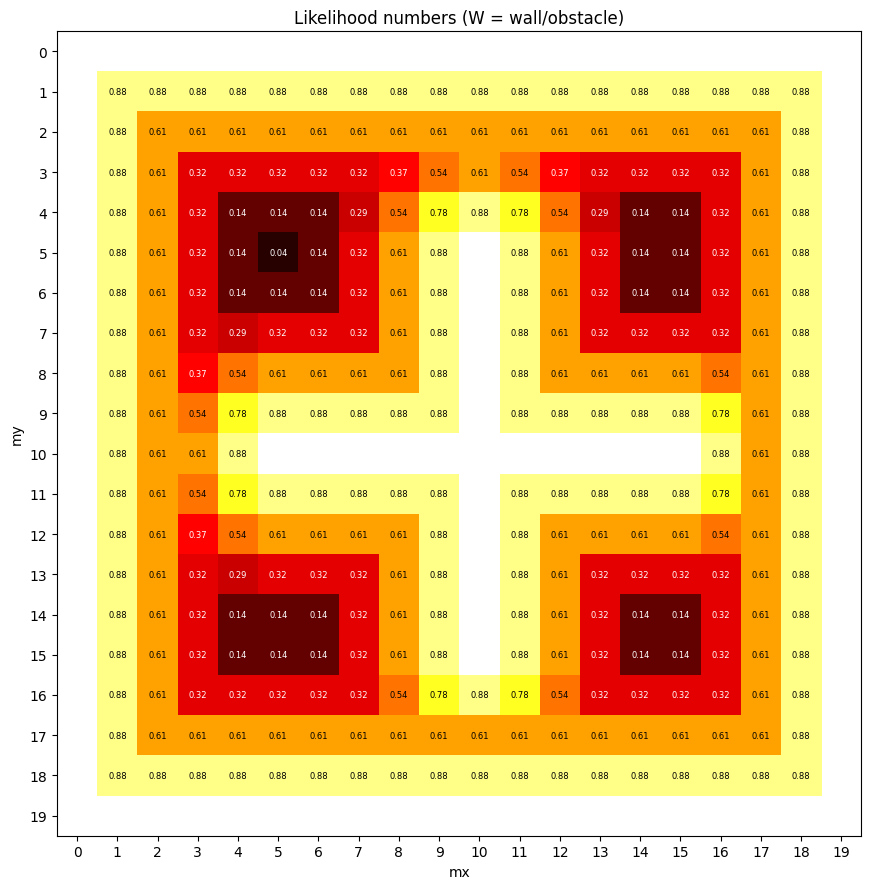

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
plot_grid_values(ax, grid, likelihood, "Likelihood numbers (W = wall/obstacle)", "hot", fmt=".2f", text_white_below=0.5)
plt.tight_layout()
plt.show()

### Optional: distance numbers on the grid

Same idea but showing **distance to nearest obstacle** (in cells) in each free cell.

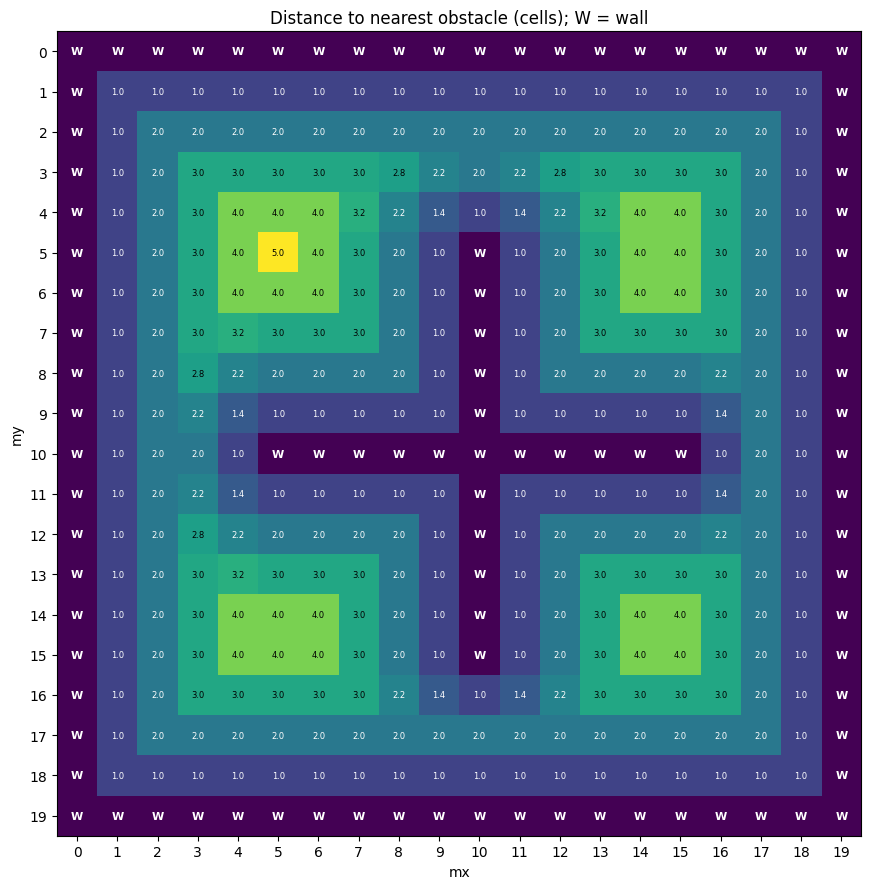

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
plot_grid_values(ax, grid, dist_map, "Distance to nearest obstacle (cells); W = wall", "viridis", fmt=".1f", text_white_below=dist_map.max() * 0.5)
plt.tight_layout()
plt.show()

## Summary

- **Occupancy grid**: 20×20 with free (0) and occupied (1) cells.
- **Distance map**: Precomputed for every cell (expand or EDT); used at runtime for fast lookup (e.g. beam endpoints in MCL). Optionally returns nearest-obstacle indices for visualization.
- **Nearest occupied cell**: Expanding-square checks rings around each cell until an obstacle is found; EDT returns both distance and nearest-cell indices in one pass.
- **Likelihood field**: `likelihood = exp(-0.5 * (d/σ)²)` so that cells close to walls have high likelihood and cells far from walls have low likelihood. The diagram with numbers shows this pattern on the small grid.

## 5. Benchmarking: distance map methods (expand vs Chamfer vs EDT)

The **expanding-square** method is simple but costs O(cells × search_area) per map. The **Meijster algorithm** (and similar linear-time methods) compute the **Euclidean distance transform** in O(n) time. SciPy provides `scipy.ndimage.distance_transform_edt`, which implements an O(n) EDT. This section times expanding-square, a two-pass Chamfer method, and SciPy EDT on the 20×20 grid and on larger grids, and checks that the results match.

20×20 grid:
  Expanding-square: 7.76 ms (mean over 5 runs)
  Chamfer (two-pass): 0.69 ms (mean over 5 runs)
  EDT (Meijster-style): 0.06 ms (mean over 5 runs)
  Max |expand - EDT|: 2.071068
  Max |expand - Chamfer|: 2.071068


Small grids (expand + Chamfer + EDT):   0%|          | 0/5 [00:00<?, ?it/s]

Large grids (Chamfer + EDT):   0%|          | 0/3 [00:00<?, ?it/s]

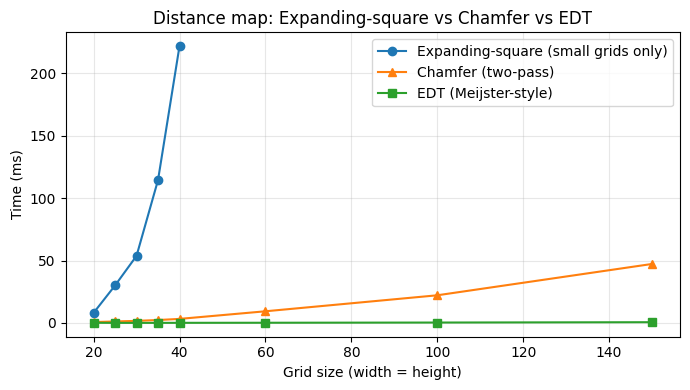

In [9]:
import time
from tqdm.auto import tqdm

# EDT benchmark uses compute_distance_map(..., method='edt') from Section 2 (no duplicate implementation).
# Chamfer is only used here for comparison.
def distance_map_chamfer(grid):
    """
    Distance from each cell to nearest occupied cell via two-pass Chamfer.

    Hybrid method: two passes over the grid (forward and backward) with
    weights 1 (cardinal) and sqrt(2) (diagonal), giving exact Euclidean
    distance on a 2D grid in O(n) time.

    Parameters
    ----------
    grid : np.ndarray
        2D occupancy grid (0 = free, 1 = occupied).

    Returns
    -------
    np.ndarray
        2D float64 array of same shape: Euclidean distance to nearest
        obstacle at each cell; occupied cells remain 0.
    """
    h, w = grid.shape
    inf = float(w + h) * np.sqrt(2)
    d = np.where(grid == 1, 0.0, inf).astype(np.float64)
    d2 = np.sqrt(2.0)
    for i in range(h):
        for j in range(w):
            if d[i, j] == 0:
                continue
            m = d[i, j]
            if i > 0:
                m = min(m, d[i - 1, j] + 1)
            if j > 0:
                m = min(m, d[i, j - 1] + 1)
            if i > 0 and j > 0:
                m = min(m, d[i - 1, j - 1] + d2)
            if i > 0 and j < w - 1:
                m = min(m, d[i - 1, j + 1] + d2)
            d[i, j] = m
    for i in range(h - 1, -1, -1):
        for j in range(w - 1, -1, -1):
            if d[i, j] == 0:
                continue
            m = d[i, j]
            if i < h - 1:
                m = min(m, d[i + 1, j] + 1)
            if j < w - 1:
                m = min(m, d[i, j + 1] + 1)
            if i < h - 1 and j < w - 1:
                m = min(m, d[i + 1, j + 1] + d2)
            if i < h - 1 and j > 0:
                m = min(m, d[i + 1, j - 1] + d2)
            d[i, j] = m
    return d

# --- Compare on the 20×20 grid (requires Section 1 & 2 run: grid, compute_distance_map) ---
n_repeat = 5
t_expand = time.perf_counter()
for _ in range(n_repeat):
    d_expand = compute_distance_map(grid, method='expand')
t_expand = (time.perf_counter() - t_expand) / n_repeat

t_chamfer = time.perf_counter()
for _ in range(n_repeat):
    d_chamfer = distance_map_chamfer(grid)
t_chamfer = (time.perf_counter() - t_chamfer) / n_repeat

t_edt = time.perf_counter()
for _ in range(n_repeat):
    d_edt = compute_distance_map(grid, method='edt')
t_edt = (time.perf_counter() - t_edt) / n_repeat

diff_edt = np.abs(d_expand.astype(np.float64) - d_edt)
diff_chamfer = np.abs(d_expand.astype(np.float64) - d_chamfer)
print("20×20 grid:")
print(f"  Expanding-square: {t_expand*1000:.2f} ms (mean over {n_repeat} runs)")
print(f"  Chamfer (two-pass): {t_chamfer*1000:.2f} ms (mean over {n_repeat} runs)")
print(f"  EDT (Meijster-style): {t_edt*1000:.2f} ms (mean over {n_repeat} runs)")
print(f"  Max |expand - EDT|: {np.nanmax(diff_edt):.6f}")
print(f"  Max |expand - Chamfer|: {np.nanmax(diff_chamfer):.6f}")

# --- Scale to larger grids ---
def make_grid(size):
    """Build a square occupancy grid with border and cross for benchmarking."""
    g = np.zeros((size, size), dtype=np.int32)
    g[0, :] = g[-1, :] = g[:, 0] = g[:, -1] = 1
    g[size//2, size//4:3*size//4] = 1
    g[size//4:3*size//4, size//2] = 1
    return g

sizes = [20, 25, 30, 35, 40]
times_expand = []
times_chamfer = []
times_edt = []
for s in tqdm(sizes, desc="Small grids (expand + Chamfer + EDT)"):
    g = make_grid(s)
    t0 = time.perf_counter()
    compute_distance_map(g, method='expand', max_dist=min(50, s//2))
    times_expand.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    for _ in range(5):
        distance_map_chamfer(g)
    times_chamfer.append((time.perf_counter() - t0) / 5)
    t0 = time.perf_counter()
    for _ in range(5):
        compute_distance_map(g, method='edt')
    times_edt.append((time.perf_counter() - t0) / 5)

sizes_large = [60, 100, 150]
for s in tqdm(sizes_large, desc="Large grids (Chamfer + EDT)"):
    g = make_grid(s)
    times_expand.append(np.nan)
    t0 = time.perf_counter()
    for _ in range(3):
        distance_map_chamfer(g)
    times_chamfer.append((time.perf_counter() - t0) / 3)
    t0 = time.perf_counter()
    for _ in range(3):
        compute_distance_map(g, method='edt')
    times_edt.append((time.perf_counter() - t0) / 3)
    sizes.append(s)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(sizes[:5], np.array(times_expand[:5]) * 1000, "o-", label="Expanding-square (small grids only)")
ax.plot(sizes, np.array(times_chamfer) * 1000, "^-", label="Chamfer (two-pass)")
ax.plot(sizes, np.array(times_edt) * 1000, "s-", label="EDT (Meijster-style)")
ax.set_xlabel("Grid size (width = height)")
ax.set_ylabel("Time (ms)")
ax.set_title("Distance map: Expanding-square vs Chamfer vs EDT")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()